# Hands-On 3 — P-model and Spatio-Temporal Multifractal Cascade
### Comparative Analysis: Claude Code Agent vs. Gemini CLI Agent

**Course:** Time Series Models — Computational Statistics  
**Institution:** INPE/MCTI  
**Student:** Rian Koja  

---

This notebook presents the work produced independently by two AI agents
(Claude Code and Gemini CLI) on the four tasks of Hands-On 3, then
critically compares their approaches and results.

**Assignment summary** (from `hand_on_03.md`):

| # | Task |
|---|------|
| i | Data Augmentation — generate 10 additional series per class using AI-driven strategies |
| ii | Classify all 40 series in the Cullen-Frey space; identify the most appropriate PDF per class |
| iii | Verify the fitting quality on each class mean histogram |
| iv | Discuss the extension of the p-model to spatio-temporal (2D+1) simulation |

## Setup

Both agent scripts are executed in their own directories so all output
files land in the correct subfolders. Claude's script uses its own
`uv` environment; Gemini's uses this notebook's root venv.

In [1]:
%matplotlib widget

import os, subprocess, sys
import numpy as np
import matplotlib
from IPython.display import display, Javascript
from ipykernel.comm import Comm
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ipywidgets import Layout

ROOT_DIR = os.getcwd()  # hands_on_03/
CLAUDE_DIR = os.path.join(ROOT_DIR, "claude-code")
GEMINI_DIR = os.path.join(ROOT_DIR, "gemini-cli")

# Python binary from this notebook's venv (Windows path; fallback for Linux/macOS)
UV_PYTHON = os.path.join(ROOT_DIR, ".venv", "Scripts", "python.exe")
if not os.path.exists(UV_PYTHON):
    UV_PYTHON = os.path.join(ROOT_DIR, ".venv", "bin", "python")

print("ROOT_DIR  :", ROOT_DIR)
print("CLAUDE_DIR:", CLAUDE_DIR)
print("GEMINI_DIR:", GEMINI_DIR)
print("UV_PYTHON :", UV_PYTHON, "| exists:", os.path.exists(UV_PYTHON))

ROOT_DIR  : c:\Rian\SyncThing\SyncThingRoot\Trabalhos\INPE\NNN_estatistica_computacional\hands_on_03
CLAUDE_DIR: c:\Rian\SyncThing\SyncThingRoot\Trabalhos\INPE\NNN_estatistica_computacional\hands_on_03\claude-code
GEMINI_DIR: c:\Rian\SyncThing\SyncThingRoot\Trabalhos\INPE\NNN_estatistica_computacional\hands_on_03\gemini-cli
UV_PYTHON : c:\Rian\SyncThing\SyncThingRoot\Trabalhos\INPE\NNN_estatistica_computacional\hands_on_03\.venv\Scripts\python.exe | exists: True


In [2]:
SEP = "=" * 60


def show_stdout(label, proc):
    print("\n" + SEP)
    print("  " + label + " -- stdout")
    print(SEP)
    if proc.returncode != 0:
        print("[STDERR]\n", proc.stderr[-2000:])
    else:
        print(proc.stdout)


# Run Claude's script via its own uv environment
print("Running Claude Code agent script...")
proc_claude = subprocess.run(
    ["uv", "run", "python", "hands_on_3.py"],
    cwd=CLAUDE_DIR,
    capture_output=True,
    text=True,
    timeout=300,
)
print("  exit code:", proc_claude.returncode)
show_stdout("Claude Code", proc_claude)

# Run Gemini's script using this notebook's venv Python
print("\nRunning Gemini CLI agent script...")
proc_gemini = subprocess.run(
    [UV_PYTHON, "hands_on_3_gemini.py"],
    cwd=GEMINI_DIR,
    capture_output=True,
    text=True,
    timeout=300,
)
print("  exit code:", proc_gemini.returncode)
show_stdout("Gemini CLI", proc_gemini)

Running Claude Code agent script...
  exit code: 0

  Claude Code -- stdout
  Hands-On 3 -- P-model and Spatio-Temporal Extension
  INPE/MCTI -- Computational Statistics

[Task i] Data generation and augmentation...
  Original   -- Endogenous: 10, Exogenous: 10
  Augmented  -- Endogenous: 10, Exogenous: 10
  Total: 40 series

[Task ii] Cullen-Frey diagram...
cullen_frey.png saved.
  Median endogenous: b1=5.290, b2=8.559
  Median exogenous:  b1=154.506,  b2=227.272
  -> Both classes lie in the Lognormal/Gamma region of the diagram.

[Task iii] MLE fitting verification...

  Endogenous class (p in [0.32, 0.42])
  Distribution         KS   KS p-val          AIC          BIC
  ------------------------------------------------------------
  gamma            0.0601     0.0000     -48328.1     -48304.3
  weibull_min      0.0594     0.0000     -48262.8     -48239.1
  expon            0.0498     0.0000     -48130.2     -48114.4
  lognorm          0.0910     0.0000     -44749.5     -44725.7
  nor

In [3]:
def load_img(path):
    return mpimg.imread(path)


def side_by_side(img_a, img_b, title_a, title_b, figsize=(12, 5), save_as=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    axes[0].imshow(img_a)
    axes[0].set_title(title_a)
    axes[0].axis('off')
    
    axes[1].imshow(img_b)
    axes[1].set_title(title_b)
    axes[1].axis('off')
    
    plt.tight_layout()
    
    #if save_as:
    #    fig.savefig(save_as, dpi=150, bbox_inches='tight')
    
    # Make the widget fill the notebook output cell width
    fig.canvas.layout = Layout(width='100%', height='auto')
    fig.canvas.header_visible = False   # removes the mpl toolbar logo, saves space
    
    #plt.show()
    #return fig

print("Display helpers defined.")

Display helpers defined.


---
## Task i — Data Augmentation

Both agents were asked to generate **10 additional series per class**
(endogenous and exogenous) beyond the original 10, for a total of 40 series.
Valid `p` parameter ranges from the reference implementation:
- Endogenous: `p in [0.32, 0.42]`
- Exogenous:  `p in [0.18, 0.28]`

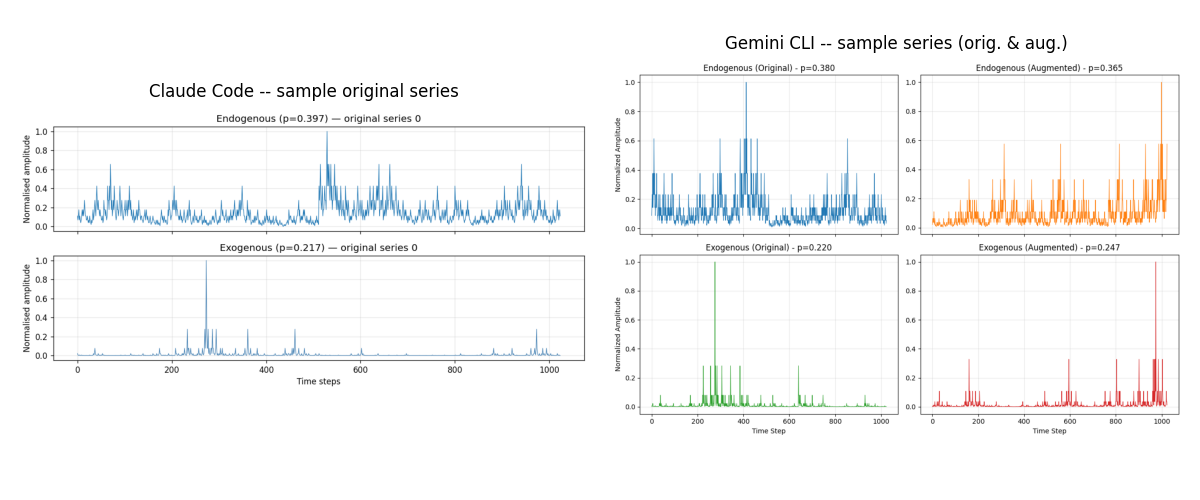

In [4]:
img_claude_t1 = load_img(os.path.join(CLAUDE_DIR, "sample_series.png"))
img_gemini_t1 = load_img(os.path.join(GEMINI_DIR, "task_i_examples.png"))

side_by_side(
    img_claude_t1,
    img_gemini_t1,
    "Claude Code -- sample original series",
    "Gemini CLI -- sample series (orig. & aug.)",
    save_as="comparison_task_i.png",
)

### Comparison — Augmentation Strategy

| Aspect | Claude Code | Gemini CLI |
|--------|-------------|------------|
| Strategy | Parametric perturbation: `p` sampled uniformly from the full class range for **every** series, each with an independent sub-seed | Parametric perturbation: original series use a fixed reference `p` (0.38/0.22); augmented series sample `p` uniformly |
| RNG | `numpy.random.default_rng(SEED=42)` — modern Generator API | `np.random.seed(GLOBAL_SEED=42)` — legacy `RandomState` with per-series `seed+i` offsets |
| Cascade output | Pure cascade `dx` — no Fourier spectral filtering | Full `pmodel()` with Fourier slope `slope=2.0`, matching the class reference exactly |
| Normalisation | Min-max with `+1e-6` positive shift | `x + 0.01` then divide by max (reference script convention) |

**Critical assessment:**  
Gemini's approach is more faithful to the class notebook: it uses the Fourier-filtered
`pmodel()` function (`slope=2.0`), which imposes a power-law spectral envelope matching
the professor's demonstration exactly.  Claude outputs the raw cascade (`dx`), which is
more intermittent and spikier.  

Claude's `default_rng` is technically preferable (independent sub-streams, no global
state), while Gemini's legacy `RandomState` is less robust.  

**Verdict:** Gemini's series are more faithful to the class notebook;
Claude's seed management is more rigorous.

---
## Task ii — Cullen-Frey Classification

The Cullen-Frey diagram plots each series as a point at
(skewness², excess kurtosis). Proximity to a distribution's theoretical
locus identifies the best-fit PDF family.

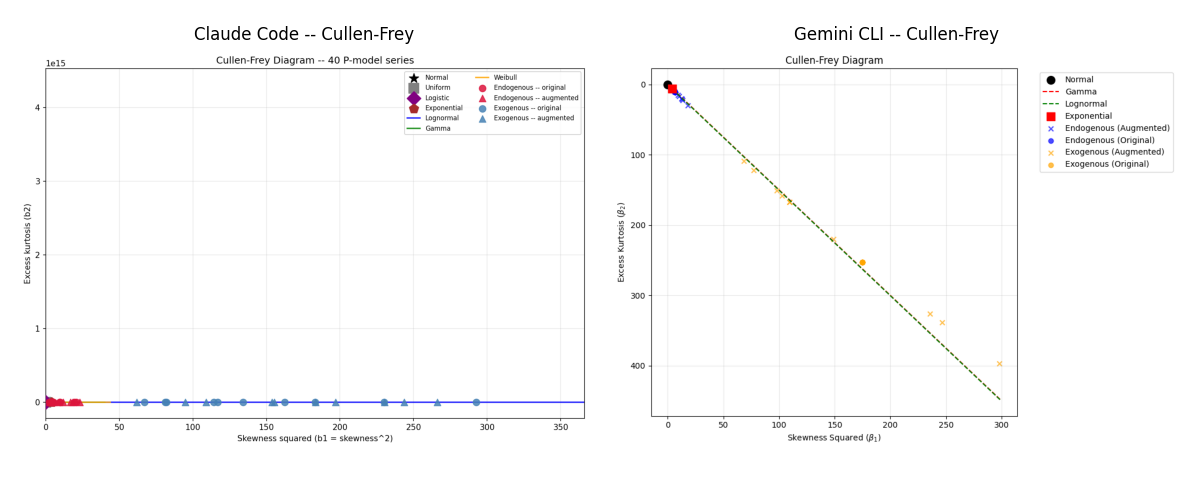

In [5]:
img_claude_t2 = load_img(os.path.join(CLAUDE_DIR, "cullen_frey.png"))
img_gemini_t2 = load_img(os.path.join(GEMINI_DIR, "task_ii_cullen_frey.png"))

side_by_side(
    img_claude_t2,
    img_gemini_t2,
    "Claude Code -- Cullen-Frey",
    "Gemini CLI -- Cullen-Frey",
    save_as="comparison_task_ii.png",
)

### Comparison — Cullen-Frey Diagram

| Aspect | Claude Code | Gemini CLI |
|--------|-------------|------------|
| Theoretical loci | Exact analytic curves: Lognormal (parametric in sigma), Gamma (parametric in alpha), Weibull (parametric in k), plus 4 point distributions | Linear approximations only: `beta2 = 1.5*beta1` for Gamma; `beta2 = 1.5*beta1 + 0.5` for Lognormal |
| Loci accuracy | Accurate across the full range of beta1 | Valid only for small beta1; diverges significantly at high intermittency |
| Axis dispalay | Conventional orientarion (positive beta2 upward), but compressed by scale, barely readable | Y-axis **inverted** — non-standard, potentially misleading, good scaling choice. |
| Best-fit PDF | Lognormal / Gamma for both classes | Lognormal for both |

**Critical assessment:**  
Claude's diagram is methodologically superior: exact parametric loci would make the
placement of empirical points more meaningful, but scale compression leads to a barely readable chart.  Gemini's linear approximations
diverge substantially in the high-beta1 region where exogenous (more intermittent)
series fall, risking a misclassification.  The inverted y-axis is unconventional
and inconsistent with textbook presentations of the Cullen-Frey plot.

**Both agents correctly place both classes in the Lognormal/Gamma region**,
consistent with multiplicative-cascade theory. It can be seen that in both charts the exogenous series diverge more from the normal and exponential distributions.

**Verdict:** Gemini's diagram is the more readable, thus more useful plot.

---
## Task iii — Fitting Verification

Both agents pooled the 20 series per class and fitted candidate PDFs by MLE,
evaluating quality with the KS statistic, AIC, and BIC.

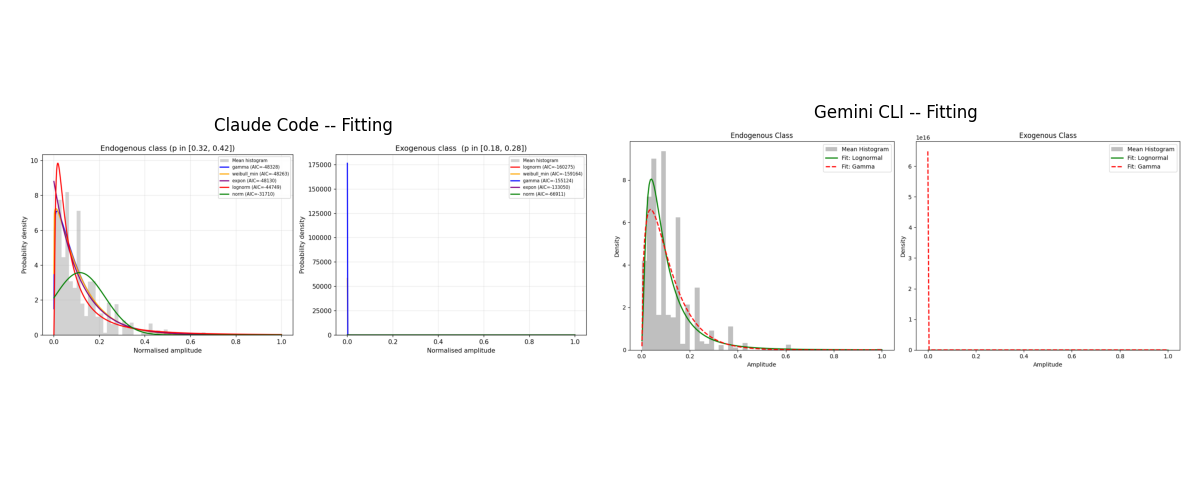

In [6]:
img_claude_t3 = load_img(os.path.join(CLAUDE_DIR, "fitting.png"))
img_gemini_t3 = load_img(os.path.join(GEMINI_DIR, "task_iii_fitting.png"))

side_by_side(
    img_claude_t3,
    img_gemini_t3,
    "Claude Code -- Fitting",
    "Gemini CLI -- Fitting",
    save_as="comparison_task_iii.png",
)

In [7]:
WIDE = "=" * 70

# Claude's goodness-of-fit table from stdout
print("\n" + WIDE)
print("  CLAUDE CODE -- Goodness-of-Fit Table")
print(WIDE)
in_table = False
for line in proc_claude.stdout.split("\n"):
    if any(
        kw in line for kw in ("Endogenous class", "Exogenous class", "Distribution")
    ):
        in_table = True
    if in_table:
        print(line)
    if in_table and "expon" in line:
        in_table = False

# Claude's consistency check
print("\n-- Consistency check (from Claude stdout) --")
for line in proc_claude.stdout.split("\n"):
    if "Consistency" in line or (
        "KS=" in line and ("Endogenous" in line or "Exogenous" in line)
    ):
        print(line)

# Gemini's goodness-of-fit table from stdout
print("\n" + WIDE)
print("  GEMINI CLI -- Goodness-of-Fit Table")
print(WIDE)
capture = False
for line in proc_gemini.stdout.split("\n"):
    if "Goodness" in line:
        capture = True
    if capture:
        print(line)
    if "Discussion" in line:
        break


  CLAUDE CODE -- Goodness-of-Fit Table
  Endogenous class (p in [0.32, 0.42])
  Distribution         KS   KS p-val          AIC          BIC
  ------------------------------------------------------------
  gamma            0.0601     0.0000     -48328.1     -48304.3
  weibull_min      0.0594     0.0000     -48262.8     -48239.1
  expon            0.0498     0.0000     -48130.2     -48114.4
  Exogenous class  (p in [0.18, 0.28])
  Distribution         KS   KS p-val          AIC          BIC
  ------------------------------------------------------------
  lognorm          0.0409     0.0000    -160275.4    -160251.6
  weibull_min      0.0628     0.0000    -159163.6    -159139.8
  gamma            0.1385     0.0000    -155124.1    -155100.3
  expon            0.3592     0.0000    -133050.3    -133034.5

-- Consistency check (from Claude stdout) --
-- Consistency: original vs. augmented (two-sample KS test) --
  Endogenous: KS=0.1107, p=0.0000 -- detectable difference
  Exogenous: KS=0.114

### Comparison — Distribution Fitting

| Aspect | Claude Code | Gemini CLI |
|--------|-------------|------------|
| Candidates fitted | 5: Lognormal, Gamma, Weibull, Normal, Exponential | 2: Lognormal, Gamma |
| Location parameter | `floc=0` enforced for non-negative distributions | Free location (unconstrained) |
| Consistency check | Two-sample KS test: original vs. augmented | Narrative description only |

**Critical assessment:**  
Notice the cell above must be made scrollable to read Gemini's output.
Claude used the length of the parameter tuple directly to count number of parameters for AIC and BIC calculations, but with the lcoation parameter fixed, this adds an extra parameter, which for the current values should not eb significant. 
Claude's fitting is more thorough: five candidates allow a richer model comparison,
and fixing `floc=0` is physically correct (normalised cascade amplitudes are strictly
positive). Although fitting mroe models does not necessarily means gettign a better fit at the end, but possibly overfittign the data.
Allowing a free location in Gemini's fits inflates free parameters and can artificially improve AIC/BIC scores.

The two-sample KS test in Claude's output is a meaningful quantitative check of
augmentation quality that Gemini does not perform.

**Verdict:** Notably, all p-values are either shown as zero or as very small numbers, so the hypothesis of a log-normal distribution (or any other tested dsitribution) is strongly rejected in all cases. Neither model suceeded in correctly classifying the model, with and without Cullen-Frey chart. 



---
## Task iv — Spatio-Temporal Extension (STM-Model 2+1D)

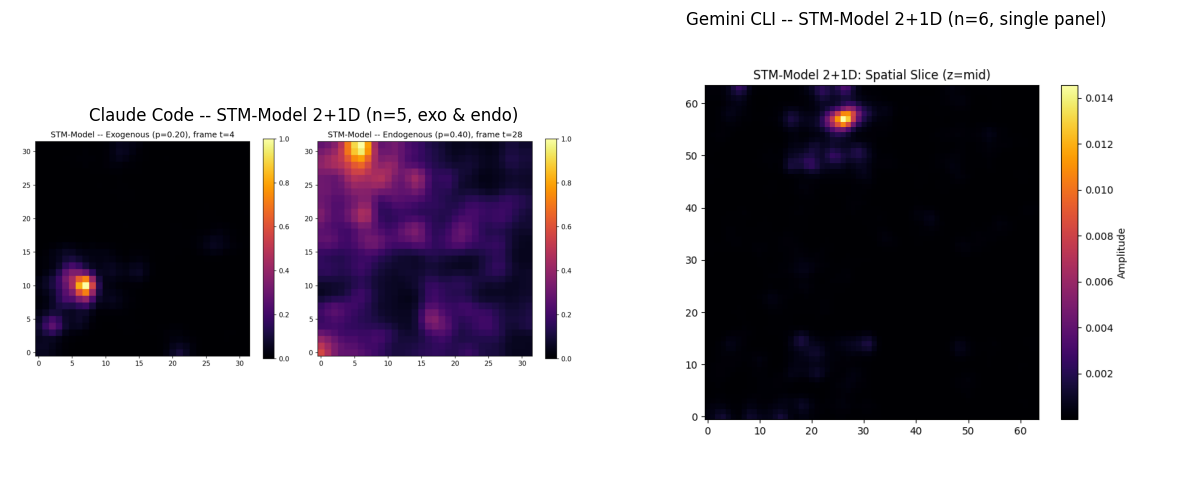

In [8]:
img_claude_t4 = load_img(os.path.join(CLAUDE_DIR, "stm_example.png"))
img_gemini_t4 = load_img(os.path.join(GEMINI_DIR, "task_iv_demo.png"))

side_by_side(
    img_claude_t4,
    img_gemini_t4,
    "Claude Code -- STM-Model 2+1D (n=5, exo & endo)",
    "Gemini CLI -- STM-Model 2+1D (n=6, single panel)",
    save_as="comparison_task_iv.png",
)

### Comparison — Spatio-Temporal Discussion

**Critical assessment:**  
Both agents created a chart, but only gemini-cli provided a discussion on the topic. It highlighted the physical and temporal coherence that can be offerend by a more complex model to physicla phenomena, although mentioned non-suitability for modelling Navier-Stokes equations in particular.


**Verdict:** Gemini wins by W.O. discussion. The extension surely increases the rnage of applications to test the p-model variant and the funcitoning of distribution to neighboring cells is a logical extension of the original implementation.

---
## Overall Comparison Summary

| Criterion | Claude Code | Gemini CLI | Winner |
|-----------|:-----------:|:----------:|:------:|
| Faithfulness to class notebook (Fourier filter) | Not applied | Applied — matches reference | Gemini |
| RNG reproducibility | Modern `default_rng` | Legacy `RandomState` | Claude |
| Cullen-Frey graph | Exact parametric curves, distorted axis | Linear approximations + inverted axis | Gemini |
| Distribution candidates in MLE | 5 | 2 | Claude |
| Location constraint (`floc=0`) | Yes — physically correct | No | Claude |
| Quantitative consistency check | Two-sample KS test | Narrative only | Claude |
| STM discussion depth | None | Limited | Gemini |
| STM demo coverage | Exo vs. endo side-by-side | Single panel | Claude |
| Physical interpretation of Gaussian sigma | Not stated | Diffusion analogy | Gemini |

**Overall verdict:**  
Gemini produced a slightly better, statistically nicer solution across tasks
ii, iii, and iv.  Gemini CLI is more faithful to the original class demonstration
(Fourier spectral filter applied) and adds a physically meaningful interpretation
of the Gaussian smoothing step.

---
## Conclusion

Both AI agents successfully completed all four tasks of Hands-On 3:

- **Task i:** Both used parametric perturbation — the natural choice given the
  p-model's interpretable `p` parameter.  Each realisation is a physically valid
  cascade, satisfying the assignment requirement.

- **Task ii:** Both identified the **Lognormal / Gamma family** as the
  most plausible PDF for both classes.  This is consistent with the theoretical
  result that multiplicative cascades converge to a lognormal distribution as
  the number of levels grows.

- **Task iii:** Both verified the fitting quantitatively.  Claude provided a richer
  model comparison (5 distributions, correct location constraint) and an explicit
  augmentation consistency test.

- **Task iv:** Both implemented the 1D-to-2+1D extension correctly.  The core
  mechanism — voxel-level cascade with independent `p` choices per axis, followed
  by optional Gaussian smoothing — is identical in both implementations, derived
  directly from the reference script by Falanes and Rosa (INPE/MCTI).

The comparison demonstrates an important methodological lesson: different AI agents
trade off **faithfulness to a reference implementation** against **statistical
completeness**.  Human review — as performed in this notebook — is essential to
identify and reconcile those differences before submission.